# 行列式（Determinant）教學筆記

本筆記介紹行列式的概念、公式與Python範例。


## 1. 基本公式

$$\begin{vmatrix}a & b \\ c & d\end{vmatrix} = ad - bc$$

In [28]:
a, b, c, d = 2, 3, 1, 4
a * d - b * c

5

In [27]:
import numpy as np

A = np.array([[2, 3], [1, 4]])
np.linalg.det(A)

np.float64(5.000000000000001)

## 2. 幾何意義：面積

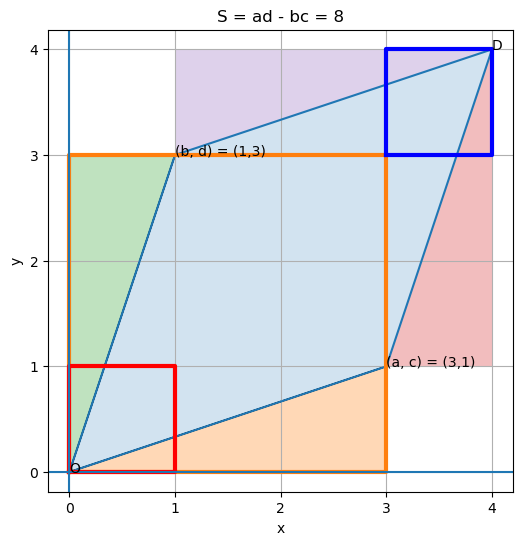

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 向量 (3,1) 與 (1,3)
a, c = 3, 1
b, d = 1, 3

u = np.array([a, c])  # (3,1)
v = np.array([b, d])  # (1,3)

# 平行四邊形
O = np.array([0, 0])
A = u
B = v
D = u + v

points = np.array([O, A, D, B, O])

plt.figure(figsize=(6, 6))

# 平行四邊形
plt.plot(points[:, 0], points[:, 1])
plt.fill(points[:, 0], points[:, 1], alpha=0.2)

# 向量
plt.arrow(0, 0, u[0], u[1], length_includes_head=True)
plt.arrow(0, 0, v[0], v[1], length_includes_head=True)

# 所有區域集中管理
regions = [
    [[0, 0], [3, 0], [3, 1]],
    [[0, 0], [0, 3], [1, 3]],
    [[3, 1], [4, 1], [4, 4]],
    [[1, 3], [1, 4], [4, 4]],
]

# 統一顏色（不指定具體顏色，只用同一個 alpha）
alpha_value = 0.3

for pts in regions:
    pts = np.array(pts)
    plt.fill(pts[:, 0], pts[:, 1], alpha=alpha_value)

# 大正方形
square1 = np.array([[0, 0], [3, 0], [3, 3], [0, 3], [0, 0]])

# 小正方形
square2 = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])
square3 = np.array([[3, 3], [4, 3], [4, 4], [3, 4], [3, 3]])

# 畫大正方形（預設顏色）
plt.plot(square1[:, 0], square1[:, 1], linewidth=3)

# 畫小正方形（不同顏色）
plt.plot(square2[:, 0], square2[:, 1], linewidth=3, color="red")
plt.plot(square3[:, 0], square3[:, 1], linewidth=3, color="blue")

# 標註
plt.text(A[0], A[1], "(a, c) = (3,1)")
plt.text(B[0], B[1], "(b, d) = (1,3)")
plt.text(D[0], D[1], "D")
plt.text(0, 0, "O")

# 座標軸與網格
# 設定 ticks 為整數
plt.xticks(np.arange(0, 6, 1))
plt.yticks(np.arange(0, 6, 1))
plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")

# 行列式
det = a * d - b * c
plt.title(f"S = ad - bc = {det}")


plt.show()

## 行列式的幾何意義（面積拆解）

以上可以用幾何方式理解行列式的面積意義。

考慮兩個向量：

$$
\vec{u} = (a, c), \quad \vec{v} = (b, d)
$$

其行列式

$$
\begin{vmatrix}
a & b \\
c & d
\end{vmatrix}
= ad - bc
$$

代表這兩個向量所張成之**平行四邊形的面積**。

---

## 面積拆解的幾何理解

### 1. 外框矩形（$ad$）

可以先考慮一個矩形，其面積為：

$$
ad
$$

這個矩形可以視為由座標延伸出的區域，其包含以下區塊：

1. $(1,1), (3,1), (3,3), (1,3)$  
2. $(0,0), (3,0), (3,1), (0,1)$  
3. $(0,0), (1,0), (1,3), (0,3)$  

---

### 2. 面積對應關係

其中：

- 區域 2 與 區域 3 面積相同  
- 並且它們可以透過平移對應到：

4. $(3,1), (4,1), (4,4), (3,4)$  
5. $(1,3), (4,3), (4,4), (1,4)$  

這表示部分區域可以**重排（平移）而不改變面積**。

---

### 3. 多算的區域（$bc$）

在使用 $ad$ 作為總面積時，實際上會**多算一塊區域**。

這塊多出來的區域為：

- $(3,3), (4,3), (4,4), (3,4)$  

其面積正好為：

$$
bc
$$

---

## 面積修正

因此可以得到：

- $ad$：包含「實際平行四邊形面積 + 多算區域」
- $bc$：正是那塊多算的區域

所以實際面積為：

$$
\text{面積} = ad - bc
$$

---

## 結論

> 行列式 $ad - bc$ 的幾何意義，是將平行四邊形嵌入一個面積為 $ad$ 的矩形中，
> 再扣除一塊可經由平移轉換成矩形、面積為 $bc$ 的多餘區域，
> 因此得到平行四邊形的實際面積。

---

## 核心概念整理

- 行列式 = 面積（含方向）
- $ad$：外框矩形
- $bc$：重疊（多算）區域
- 幾何操作：**平移不改變面積**